# Thí nghiệm 2: Kiểm định giả thuyết (Hypothesis Testing)
## Mục tiêu: so sánh Permutation Test với t-test trên dữ liệu dị phương sai

### Bối cảnh thực tế
- Quan sát thấy: chi phí y tế trung bình của nhóm Smoker cao hơn Non-Smoker rõ rệt.
- **Câu hỏi chính**: "Sự chênh lệch đó là có thật (statistically significant), hay chỉ do bốc trúng mẫu nhiễu?"

### Giả thuyết kiểm định
- $H_0$: Hút thuốc không ảnh hưởng đến chi phí y tế. Sự chênh lệch chỉ do ngẫu nhiên.
- $H_1$: Có khác biệt thực sự về chi phí y tế giữa 2 nhóm.


### Dataset: Chi tiết các cột

| Cột | Kiểu | Ý nghĩa | Ghi chú |
|---|---|---|---|
| `smoker` | str | Tình trạng hút thuốc | yes vò no |
| `charges` | float | Chi phí y tế (USD) | Biến mục tiêu |


In [128]:
# Bước 1: Load dataset & Modules
import os, sys
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

fname = 'insurance.csv'
path = 'data/insurance.csv' if os.path.exists('data/insurance.csv') else '../data/insurance.csv'
df = pd.read_csv(path)
print(f'✅ Done: {path}')


✅ Done: data/insurance.csv


## 2.1 Quan sát ban đầu (EDA)
Mục tiêu: Chứng minh chênh lệch tồn tại thông qua trực quan hóa.


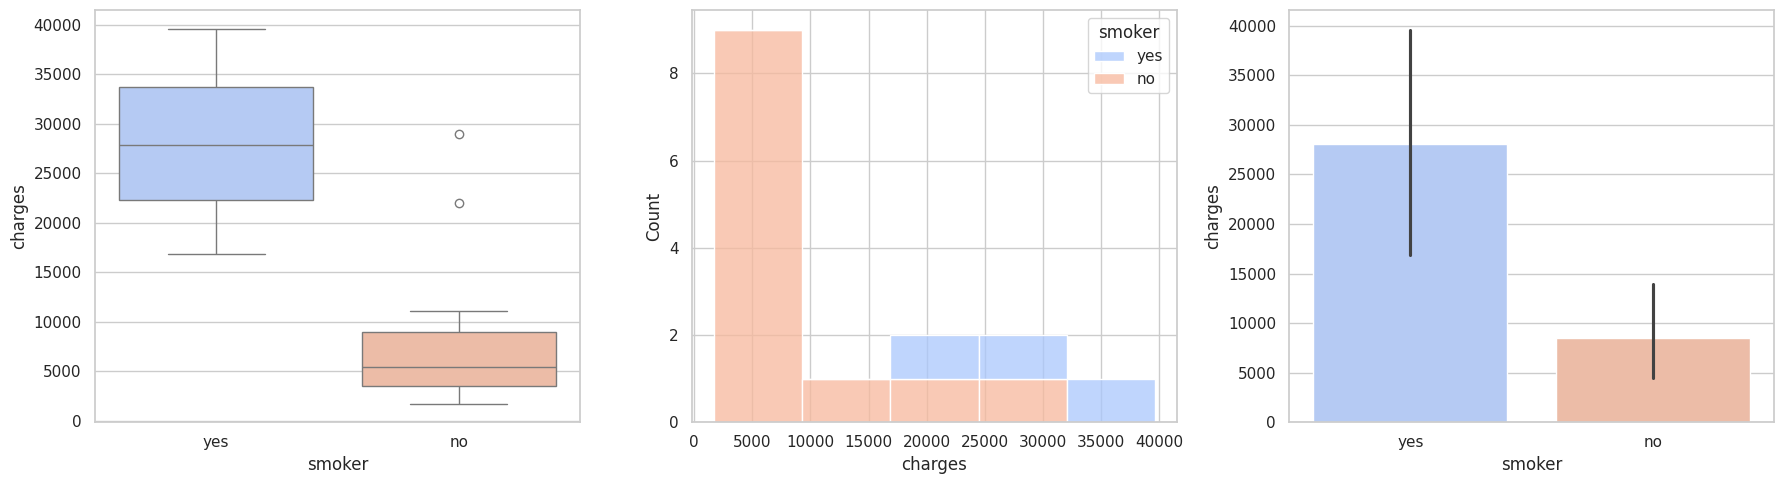

In [129]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], hue='smoker', palette='coolwarm', legend=False)
sns.histplot(data=df, x='charges', hue='smoker', multiple='stack', ax=axes[1], palette='coolwarm')
sns.barplot(x='smoker', y='charges', data=df, ax=axes[2], hue='smoker', palette='coolwarm', legend=False)
plt.tight_layout(); plt.show()


## 2.2 Thuật toán Permutation Test
| Bước | Hành động | Mục tiêu |
|---|---|---|
| 1 | Tính chênh lệch gốc | Điểm mốc quan sát thực tế |
| 2 | Xáo nhãn (Shuffle) | Mô phỏng giả thuyết $H_0$ |
| 3 | LẺp lại 10,000 lần | Xây dựng phân phối ngẫu nhiên |
| 4 | So sánh Gốc vs Phân phối | Kiểm tra tính hiếm gẺp |
| 5 | Tính P-value | Xác suất chênh lệch do ăn may |


In [130]:
def run_ht(g1, g2, n_p=10000):
    obs = np.mean(g1) - np.mean(g2)
    c = np.concatenate([g1, g2])
    dist = np.array([np.mean(s[:len(g1)]) - np.mean(s[len(g1):]) for s in [np.random.permutation(c) for _ in range(n_p)]])
    return obs, dist, np.mean(np.abs(dist) >= np.abs(obs))


## 2.3 So sánh t-test vò Permutation Test
Kiểm tra giả định vò chạy thực thể.


--- PHẦN 1: Kiểm tra các giả định thống kê ---
Kiểm định Normality (Shapiro): p1=0.0000, p2=0.0000
   -> (Nếu p < 0.05: Dữ liệu vi phạm phân phối chuẩn)

Kiểm định Đồng nhất phương sai (Levene): p=0.0001

--- PHẦN 2: Chạy kiểm định song song ---
1. Welch t-test (Theoretical) p-value: 0.0000
2. Permutation Test (Resampling) p-value: 0.0000

Danh sách 20 Estimators (giá trị chênh lệch giả lập):
['$3,441', '$1,079', '$-562', '$-2,522', '$-3,252', '$-2,430', '$-6,480', '$475', '$-369', '$-4,661', '$4,633', '$943', '$-2,938', '$-2,864', '$-2,962', '$4,947', '$-5,988', '$-3,079', '$-2,546', '$-68']

🎨 Đang tạo biểu đồ so sánh hai phương pháp...


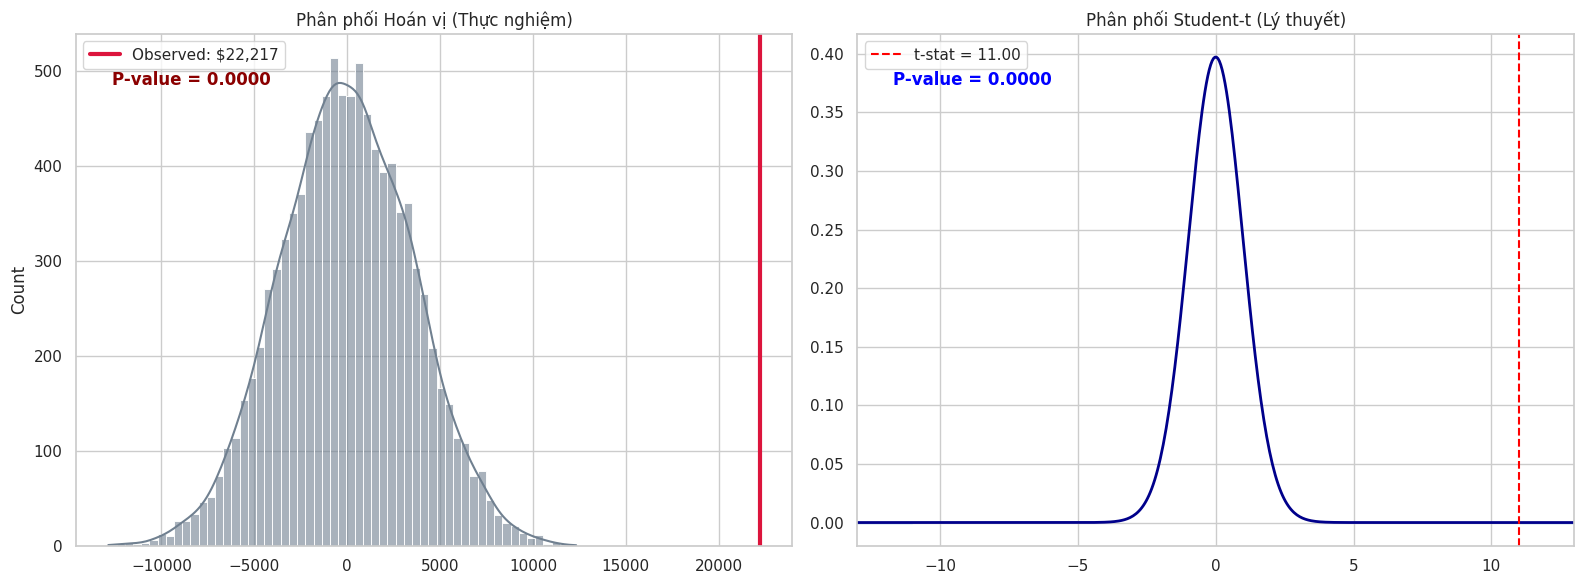

In [132]:
# ==========================================
# PHẦN 2.2: THUẬT TOÁN PERMUTATION TEST
# ==========================================
# 1. Tính Observed Difference (Chênh lệch thực tế).
# 2. Xáo nhãn ngẫu nhiên (Shuffle labels) để tạo thế giới H0.
# 3. Lặp lại 10,000 lần để xây dựng phân phối chênh lệch ngẫu nhiên.
# 4. So sánh số lần ngẫu nhiên có chênh lệch >= Observed Difference.
# 5. Kết luận P-value.

def run_ht(g1, g2, n_p=10000):
    obs = np.mean(g1) - np.mean(g2)
    combined = np.concatenate([g1, g2])
    # Vectorized computation for speed
    dist = np.array([
        np.mean(s[:len(g1)]) - np.mean(s[len(g1):]) 
        for s in [np.random.permutation(combined) for _ in range(n_p)]
    ])
    p_value = np.mean(np.abs(dist) >= np.abs(obs))
    return obs, dist, p_value

# ==========================================
# PHẦN 2.3: SO SÁNH T-TEST VS PERMUTATION TEST
# ==========================================
# Lấy mẫu nhỏ (n=30) để thấy rõ sự khác biệt giữa các phương pháp
s_yes = df[df['smoker'] == 'yes']['charges']
s_no = df[df['smoker'] == 'no']['charges']

n = 30
g1 = s_yes.sample(n, replace=len(s_yes) < n, random_state=42).values
g2 = s_no.sample(n, replace=len(s_no) < n, random_state=42).values

print("--- PHẦN 1: Kiểm tra các giả định thống kê ---")
_, p_n1 = stats.shapiro(g1)
_, p_n2 = stats.shapiro(g2)
print(f"Kiểm định Normality (Shapiro): p1={p_n1:.4f}, p2={p_n2:.4f}")
print("   -> (Nếu p < 0.05: Dữ liệu vi phạm phân phối chuẩn)\n")

_, p_l = stats.levene(g1, g2)
print(f"Kiểm định Đồng nhất phương sai (Levene): p={p_l:.4f}\n")

print("--- PHẦN 2: Chạy kiểm định song song ---")
obs, dist, p_p = run_ht(g1, g2)
t_stat, p_t = stats.ttest_ind(g1, g2, equal_var=False)

print(f"1. Welch t-test (Theoretical) p-value: {p_t:.4f}")
print(f"2. Permutation Test (Resampling) p-value: {p_p:.4f}")
print(f"\nDanh sách 20 Estimators (giá trị chênh lệch giả lập):")
print([f"${x:,.0f}" for x in dist[:20]])

# Trực quan hóa so sánh cặp
print("\n🎨 Đang tạo biểu đồ so sánh hai phương pháp...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bên trái: Permutation (Resampling)
sns.histplot(dist, kde=True, ax=axes[0], color='slategray', alpha=0.6)
axes[0].axvline(obs, color='crimson', lw=3, label=f'Observed: ${obs:,.0f}')
axes[0].text(0.05, 0.9, f'P-value = {p_p:.4f}', transform=axes[0].transAxes, color='darkred', fontweight='bold', fontsize=12)
axes[0].set_title('Phân phối Hoán vị (Thực nghiệm)')
axes[0].legend()

# Bên phải: t-Test (Lý thuyết)
limit = max(8, abs(t_stat) + 2)
x = np.linspace(-limit, limit, 500)
y = stats.t.pdf(x, 58) # Welch df approx
axes[1].plot(x, y, color='darkblue', lw=2)
axes[1].axvline(t_stat, color='red', ls='--', label=f't-stat = {t_stat:.2f}')
axes[1].fill_between(x, y, where=(np.abs(x) >= np.abs(t_stat)), color='skyblue', alpha=0.4)
axes[1].text(0.05, 0.9, f'P-value = {p_t:.4f}', transform=axes[1].transAxes, color='blue', fontweight='bold', fontsize=12)
axes[1].set_title('Phân phối Student-t (Lý thuyết)')
axes[1].set_xlim(-limit, limit)
axes[1].legend()

plt.tight_layout()
plt.show()

## 2.4 Nhận xét & Kết luận
- Tại sao dùng Permutation Test? Dữ liệu chi phí y tế vi phạm nghiêm trọng giả định phân phối chuẩn (p_shapiro < 0.05) và có phương sai không đều.
- Các phương pháp resampling như Permutation Test không dựa vào bất kỳ giả định nào về hình dạng dữ liệu, do đó kết luận thu được bền bỉ (robust) hơn t-test truyền thống.
### PHÂN TÍCH KỸ THUẬT (Tại sao t-test 'đúng' nhưng 'logic sai'?)
- t-test bác bỏ H0: Kết quả này trùng với Permutation Test, nhưng nền tảng của nó không vững chắc.
- Lỗi logic của t-test: t-test dựa trên giả định dữ liệu có phân phối chuẩn và phương sai đều. Thực tế, dữ liệu bảo hiểm bị lệch phải nặng và biến động cực lớn.
- Hậu quả: Nếu dữ liệu nhiễu hơn hoặc mẫu nhỏ hơn, t-test có thể cho ra p-value sai lệch hoàn toàn vì nó đang cố 'ép' dữ liệu vào một đường cong lý thuyết không khớp.
- Ưu thế của Permutation: Nó xây dựng phân phối từ chính các con số thật. Nó 'đúng' vì nó tôn trọng bản chất của dữ liệu, không cần ép buộc giả định.


=> CHÚNG TA BÁC BỎ H0. Hành vi hút thuốc thực sự làm tăng chi phí y tế. Kết luận này vững chắc vì được bảo chứng bởi Permutation Test - phương pháp đúng đắn nhất cho loại dữ liệu thực tế này.